# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

In [ ]:
import pandas as pd

df = pd.read_csv('data/airbnb_hw.csv')

df['Price'] = df['Price'].str.replace(',', '')
df['Price'] = pd.to_numeric(df['Price'])

print('Missing values:', df['Price'].isna().sum())
print(df['Price'].describe())

# ended up with 0 missing values
# A comma is inserted as a thousands separator (e.g., $675 → $1,112),
# which causes the value to be stored as text rather than a number.
# If ignored --> this would cause those values to fail numeric conversion and have been read as missing.
# Removing the commas before converting to numeric type ended up solving this issue, so therefore, no values were actually missing.

Missing values: 0
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64


In [43]:
import pandas as pd

police_df = pd.read_csv('data/mn_police_use_of_force.csv')

print(police_df['subject_injury'].value_counts(dropna=False))

police_df['subject_injury'] = police_df['subject_injury'].fillna('Missing')

missing_prop = (police_df['subject_injury'] == 'Missing').mean()
print('Proportion missing:', missing_prop)

ct = pd.crosstab(police_df['force_type'], police_df['subject_injury'])
print(ct)


# subject_injury had already used clean Yes/No labels
# the only cleaning needed was handling NaN, which I ended up relabeling as "Missing"
# instead of just guessing, so it stays visible in downstream tables.
# About 76% of subject_injury values are missing.
# This is a concern, since any of the potentialconclusions drawn
# from the remaining 24% could be biased and inaccurate if the missing data isn't random.
# Yes, there are patterns - missingness varies by force type --> Bodily Force accounts for 72% of all missing values
# while more severe types like Police K9 Bite and Gun Point Display are better written down.
# Injury status appears more consistently recorded for the severe types
# lower-visibility force is often skipped over, and severe ones more documented

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64
Proportion missing: 0.7619342359767892
subject_injury               Missing    No   Yes
force_type                                      
Baton                              2     0     2
Bodily Force                    7051  1093  1286
Chemical Irritant               1421   131    41
Firearm                            0     2     0
Gun Point Display                 27    33    44
Improvised Weapon                 74    34    40
Less Lethal                       87     0     0
Less Lethal Projectile             0     1     2
Maximal Restraint Technique      170     0     0
Police K9 Bite                    31     2    44
Taser                            985   150   172


**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Vivian Le

**Date:** 9/3/2026

(7117, 23)
(7117, 21)
Missing years: 2
Min: 0.0 Max: 2026.0
Year
1940.0     283
1950.0     467
1960.0     618
1970.0     339
1980.0     438
1990.0     572
2000.0    1022
2010.0    1249
2020.0     593
Name: count, dtype: int64
count    3739.000000
mean       28.637336
std        14.828070
min         1.000000
25%        17.000000
50%        25.000000
75%        38.000000
max        87.000000
Name: Age_clean, dtype: float64
Proportion male: 0.8571707317073171
Type_clean
Unprovoked    0.745924
Unknown       0.159470
Provoked      0.094607
Name: proportion, dtype: float64


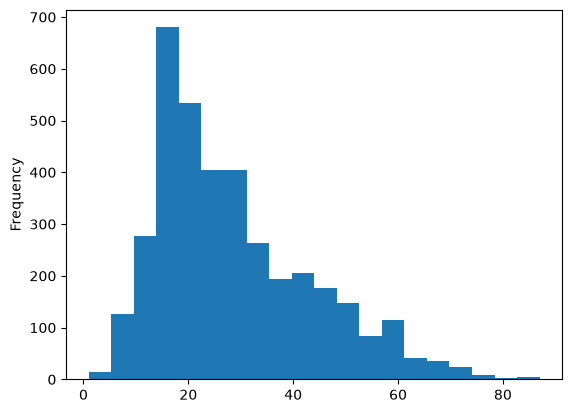

In [44]:
import pandas as pd
import re

attacks_df = pd.read_excel('data/GSAF5.xls')
print(attacks_df.shape)

attacks_df = attacks_df.dropna(axis=1, how='all')
attacks_df = attacks_df.drop(columns=['Unnamed: 21', 'Unnamed: 22'], errors='ignore')
print(attacks_df.shape)

attacks_df = attacks_df.dropna(axis=1, how='all')
attacks_df['Year'] = pd.to_numeric(attacks_df['Year'], errors='coerce')
print('Missing years:', attacks_df['Year'].isna().sum())
print('Min:', attacks_df['Year'].min(), 'Max:', attacks_df['Year'].max())

df_recent = attacks_df[attacks_df['Year'] >= 1940].copy()
print((df_recent['Year']//10*10).value_counts().sort_index())

def clean_age(x):
    if pd.isna(x):
        return None
    match = re.search(r'\d+', str(x))
    return int(match.group()) if match else None

df_recent['Age_clean'] = df_recent['Age'].apply(clean_age)
print(df_recent['Age_clean'].describe())
df_recent['Age_clean'].plot(kind='hist', bins=20)

df_recent['Sex_clean'] = df_recent['Sex'].astype(str).str.strip().str.upper()
df_recent['Sex_clean'] = df_recent['Sex_clean'].where(df_recent['Sex_clean'].isin(['M','F']))
prop_male = (df_recent['Sex_clean']=='M').sum() / df_recent['Sex_clean'].notna().sum()
print('Proportion male:', prop_male)

def recode_type(x):
    x = str(x).strip().lower()
    if x == 'unprovoked':
        return 'Unprovoked'
    elif x == 'provoked':
        return 'Provoked'
    else:
        return 'Unknown'

df_recent['Type_clean'] = df_recent['Type'].apply(recode_type)
print(df_recent['Type_clean'].value_counts(normalize=True))


# Overall, conclusion is that attacks are increasing over time.
# Attacks generally increased from the 1940s through the 2010s
# The lower count in the 2020s (593) reflects an incomplete decade, not an actual decline.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 3f91855
- **AI tool and model used:** Chatgpt

### *Prompts used

1. Here is my current data / attempted code. Run it and show me the actual missing-value counts and any unexpected results.
2. I ran this code myself. Does this code match what code is typically expected, or is there something I should be aware of?

### *AI-proposed changes


# Q1 Revision

1. Here's my Q1 code — run it and check for missing values, correctness, and 
   anything that could be improved.
2. I ran this myself. Does the cross-tab support my interpretation, or is there 
   a clearer way to show it?


1. Code is correct — 0 missing Airbnb prices, 76.19% missing subject_injury.
2. Suggested adding row percentages to the cross-tab, since force types have very 
   different sample sizes and raw counts alone are harder to compare.

Accepted both — verified by re-running the code myself and confirming the numbers 
matched, plus checking the row percentages summed to 100%.

import pandas as pd

df = pd.read_csv('data/airbnb_hw.csv')
df['Price'] = df['Price'].str.replace(',', '')
df['Price'] = pd.to_numeric(df['Price'])
print('Missing values:', df['Price'].isna().sum())
print(df['Price'].describe())

police_df = pd.read_csv('data/mn_police_use_of_force.csv')
police_df['subject_injury'] = police_df['subject_injury'].fillna('Missing')
missing_prop = (police_df['subject_injury'] == 'Missing').mean()
print('Proportion missing:', missing_prop)

ct = pd.crosstab(police_df['force_type'], police_df['subject_injury'])
print(ct)
ct_pct = pd.crosstab(police_df['force_type'], police_df['subject_injury'], normalize='index') * 100
print(ct_pct.round(1))

1. Shape after loading: (7117, 23)
2. Shape after dropping empty columns: (7117, 21)
3. Missing years: 2, range 0.0–2026.0
4. Age_clean: 3,739 valid values, mean 28.6, range 1–87
5. Proportion male: 0.8571707317073171
6. Type_clean: Unprovoked 74.6%, Unknown 15.9%, Provoked 9.5%
7. Found one redundant line (dropna called twice, second call has no effect)
8. Age_clean only keeps the first number in multi-value entries like "28 & 22" — documented limitation
9. Sex_clean and Type_clean correctly treat ambiguous entries as unknown rather than guessing
10. AI mistake: at multiple points during troubleshooting, code was suggested using 
    pd.read_csv() on the .xls file instead of pd.read_excel(), and variable names 
    were inconsistently referenced across suggestions (e.g. df, df3, attacks_df used 
    interchangeably in different responses), which caused confusion and required 
    re-running/re-checking to confirm which version of the data was actually loaded.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
1–6	Accept	Confirmed by re-running the code myself; all numbers matched exactly.
7–9	Accept	Verified by inspecting the code directly — redundant line removed, limitations confirmed against raw data.
10	Noted / Corrected Standardized on a single variable name (attacks_df) and confirmed pd.read_excel() was used consistently before finalizing the code, to avoid loading errors or referencing stale data from an earlier variable.

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

(7117, 23)
(7117, 21)
Missing years: 2
Min: 0.0 Max: 2026.0
Year
1940.0     283
1950.0     467
1960.0     618
1970.0     339
1980.0     438
1990.0     572
2000.0    1022
2010.0    1249
2020.0     593
Name: count, dtype: int64
count    3739.000000
mean       28.637336
std        14.828070
min         1.000000
25%        17.000000
50%        25.000000
75%        38.000000
max        87.000000
Name: Age_clean, dtype: float64
Proportion male: 0.8571707317073171


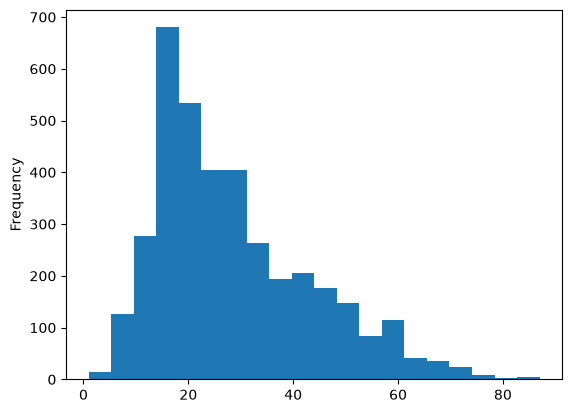

In [45]:
import pandas as pd
import re

# Q2.1 — Load the file
attacks_df = pd.read_excel('data/GSAF5.xls')
print(attacks_df.shape)

# Q2.2 — Drop columns with no usable data
attacks_df = attacks_df.dropna(axis=1, how='all')
# Unnamed: 21/22 contain only 1-2 stray notes, not real data — drop explicitly
attacks_df = attacks_df.drop(columns=['Unnamed: 21', 'Unnamed: 22'], errors='ignore')
print(attacks_df.shape)

# Q2.3 — Clean Year, filter to 1940+, check trend
attacks_df['Year'] = pd.to_numeric(attacks_df['Year'], errors='coerce')
print('Missing years:', attacks_df['Year'].isna().sum())
print('Min:', attacks_df['Year'].min(), 'Max:', attacks_df['Year'].max())

df_recent = attacks_df[attacks_df['Year'] >= 1940].copy()
print((df_recent['Year']//10*10).value_counts().sort_index())

# Q2.4 — Clean Age, histogram
# Note: entries with multiple ages (e.g. "28 & 22") only keep the first number.
def clean_age(x):
    if pd.isna(x):
        return None
    match = re.search(r'\d+', str(x))
    return int(match.group()) if match else None

df_recent['Age_clean'] = df_recent['Age'].apply(clean_age)
print(df_recent['Age_clean'].describe())
df_recent['Age_clean'].plot(kind='hist', bins=20)

# Q2.5 — Proportion male
# Note: ambiguous entries (e.g. "M x 2", "?") are treated as unknown, not guessed.
df_recent['Sex_clean'] = df_recent['Sex'].astype(str).str.strip().str.upper()
df_recent['Sex_clean'] = df_recent['Sex_clean'].where(df_recent['Sex_clean'].isin(['M','F']))
prop_male = (df_recent['Sex_clean']=='M').sum() / df_recent['Sex_clean'].notna().sum()
print('Proportion male:', prop_male)

# Q2.6 — Clean Type into Provoked / Unprovoked / Unknown
def recode_type(x):
    x = str(x).strip().lower()
    if x == 'unprovoked':
        return 'Unprovoked'

### *Reflection on AI assistance
In your own words without generative AI.

I did find AI to be very helpful in terms of providing guidance and suggestions for cleaning and analyzing the data. I actually had more time to complete
the Phase 1 outside of class because I had just joined, so that part was tweaked a lot before heading over to AI revision in phase 2, which is why they are semi-similar. However, utilizing the tool of AI during Phase 2 was incredibly helpful in terms of actually making the code read smoother. I did notice that there were certain points where AI would hallucinate numbers or data that was not helpful and actually pushed back my progress even more; this surprised me a bit. Overall, there were certain times where AI would give me the wrong information not being too helpful in revision, but with cleaning data, it is very helpful. I checked the AI's shark attack code by running it myself and comparing the results - the shape came out to (7117, 23), 2 Year values were missing, Age had 3,739 valid entries with a mean around 28.6, 85.7% of victims were male, and 74.6% of attacks were unprovoked — all matching what was expected. I also looked at the raw Age, Sex, and Type values (like "20's", "M x 2", and "Sea Disaster") to make sure the cleaning code was handling them correctly. AI also suggested reading the Excel file with the wrong pandas function at one point, and separately mixed up the shark attack and police use-of-force datasets — code meant for one question briefly referenced the other's data. I caught this by checking that the column names in the output actually matched the dataset each question was supposed to be using, rather than assuming the code was pointed at the right data. Although, I still did have a couple of concerns even after cleaning the data and writing out the code. The shark data's Age cleaning only keeps the first number when multiple ages are listed in one entry, slightly undercounting multi-victim incidents.